In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import zipfile
import math
from sklearn.metrics import accuracy_score, r2_score

In [12]:
print(tf.__version__)

2.20.0


## Unzip the data

In [13]:
zip_path = '/content/dataset_movie.zip'
extract_path = '/content/extracted_data'

if os.path.exists(zip_path):
  if(zipfile.is_zipfile(zip_path)):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)
      ratings_file = os.path.join(extract_path, "u.data")
      user_attribute_file = os.path.join(extract_path, "u.user")
      df1 = pd.read_csv(ratings_file, sep='\t', names=["userId","movieId","rating","timestamp"], engine='python')

      df1['count'] = df1.groupby('userId')['movieId'].transform('count')
      df1 = df1[df1['count'] > 300]
      # attribute file will contain the demographic data of the user
      df2 = pd.read_csv(user_attribute_file, sep='|', names=["userId","age","gender","occupation","dn"], engine='python')



In [14]:
print("Ratings Head:\n", df1.head())
print("\nUsers Head:\n", df2.head())

Ratings Head:
     userId  movieId  rating  timestamp  count
15     303      785       3  879485318    484
17     194      274       2  879539794    305
19     234     1184       2  892079237    480
24     308        1       4  887736532    397
36     181     1081       1  878962623    435

Users Head:
    userId  age gender  occupation     dn
0       1   24      M  technician  85711
1       2   53      F       other  94043
2       3   23      M      writer  32067
3       4   24      M  technician  43537
4       5   33      F       other  15213


## Data Cleaning


*   Female - 1, Male - 0
*   Don't use age for now
*   Drop time stamp too
*   Merge based on userId





In [15]:
df2['gender'] = df2['gender'].map({'F' : 1, 'M' : 0})
df3 = df2.drop(['age', 'occupation', 'dn'], axis = 1)
print("Cleaned users\n", df3.head())

df4 = df1.drop(['timestamp'], axis = 1)
df = pd.merge(df4, df3, on='userId', how='left')
print("\nMerged Dataset:\n", df.head())


Cleaned users
    userId  gender
0       1       0
1       2       1
2       3       0
3       4       0
4       5       1

Merged Dataset:
    userId  movieId  rating  count  gender
0     303      785       3    484       0
1     194      274       2    305       0
2     234     1184       2    480       0
3     308        1       4    397       0
4     181     1081       1    435       0


## Encoding Data for Embeddings

In [16]:
user_ids = df["userId"].unique().tolist()
movie_ids = df["movieId"].unique().tolist()

user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)} # For decoding later
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)} # For decoding later

# 3. Apply the mappings to create new, clean 'user' and 'movie' columns
df["user"] = df["userId"].map(user2user_encoded)
df["movie"] = df["movieId"].map(movie2movie_encoded)

In [17]:
num_users = len(user2user_encoded)
num_movies = len(movie_encoded2movie)
print(num_users, num_movies)

53 1595


In [18]:
# 5. Make sure ratings are floats (decimals) for mathematical stability
df["rating"] = df["rating"].values.astype(np.float32)

# 6. Find the min and max ratings
min_rating = min(df["rating"])
max_rating = max(df["rating"])

print(
    "Number of users: {}, Number of Movies: {}, Min rating: {}, Max rating: {}".format(
        num_users, num_movies, min_rating, max_rating
    )
)
print("\nEncoded Dataset:\n", df.head())

Number of users: 53, Number of Movies: 1595, Min rating: 1.0, Max rating: 5.0

Encoded Dataset:
    userId  movieId  rating  count  gender  user  movie
0     303      785     3.0    484       0     0      0
1     194      274     2.0    305       0     1      1
2     234     1184     2.0    480       0     2      2
3     308        1     4.0    397       0     3      3
4     181     1081     1.0    435       0     4      4


## Train & Test Split

In [20]:
df = df.sample(frac=1, random_state=42)
# extract input
x = df[["user", "movie"]].values

# xtract targets
yr = df["rating"].values
yg = df["gender"].values

# splitting
train_indices = int(0.9 * df.shape[0])
x_train, x_val = x[:train_indices], x[train_indices:]

In [54]:
# build the massive 7-lists together answer key for Multi-Task Learning!
y_train = [
    yr[:train_indices],                 # Target 1: Actual Rating
    yg[:train_indices],                 # Target 2: Gender
    yg[:train_indices],                 # Target 3: Gender
    yg[:train_indices],             # Target 4 :Fair MLP (Goal: Guess WRONG)
    yg[:train_indices],             # Target 5: Fair GMF (Goal: Guess WRONG)
    np.zeros(train_indices),            # Target 6: Zeros
    np.zeros(train_indices)             # Target 7: Zeros
]

y_val = [
    yr[train_indices:],
    yg[train_indices:],
    yg[train_indices:],
    yg[train_indices:],
    yg[train_indices:],
    np.zeros(df.shape[0]-train_indices),
    np.zeros(df.shape[0]-train_indices)
]

print('x_train shape : ', x_train.shape)
print('x_val shape   : ', x_val.shape)

x_train shape :  (18674, 2)
x_val shape   :  (2075, 2)


## FairRec NeuCF model

In [55]:
@tf.custom_gradient
def gradient_reversal(x):
    def grad(dy):
        # Multiply by -1 to reverse the gradient
        return -dy
    return x, grad

class GradientReversalLayer(layers.Layer):
    def call(self, x):
        return gradient_reversal(x)

In [56]:
EMBEDDING_SIZE = 50

class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_movies, embedding_size, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = embedding_size

        # BIAS-AWARE USER VECTORS (u^b)
        self.user_embedding_biased_mlp = layers.Embedding(
            num_users, embedding_size, embeddings_initializer="he_normal", embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.user_embedding_biased_gmf = layers.Embedding(
            num_users, embedding_size, embeddings_initializer="he_normal", embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u^d)
        self.user_embedding_fair_mlp = layers.Embedding(
            num_users, embedding_size, embeddings_initializer="he_normal", embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.user_embedding_fair_gmf = layers.Embedding(
            num_users, embedding_size, embeddings_initializer="he_normal", embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # MOVIE VECTORS (Equivalent to News Candidate Vectors e^c)
        self.movie_embedding_mlp = layers.Embedding(
            num_movies, embedding_size, embeddings_initializer="he_normal", embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.movie_embedding_gmf = layers.Embedding(
            num_movies, embedding_size, embeddings_initializer="he_normal", embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # NEUCF UTILITY LAYERS (To predict the movie rating)
        self.mlp = keras.models.Sequential([
            layers.Dense(4*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(2*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(EMBEDDING_SIZE),
        ])
        self.neuCF = layers.Dense(1)

        # DISCRIMINATOR LAYERS (To predict Gender)
        self.gender_layer_biased_mlp = layers.Dense(1)
        self.gender_layer_biased_gmf = layers.Dense(1)
        self.gender_layer_fair_mlp = layers.Dense(1)
        self.gender_layer_fair_gmf = layers.Dense(1)

    def call(self, inputs):
        # Look up the specific user and movie vectors from the matrices
        u_b_mlp = self.user_embedding_biased_mlp(inputs[:, 0])
        u_b_gmf = self.user_embedding_biased_gmf(inputs[:, 0])
        u_d_mlp = self.user_embedding_fair_mlp(inputs[:, 0])
        u_d_gmf = self.user_embedding_fair_gmf(inputs[:, 0])
        m_mlp = self.movie_embedding_mlp(inputs[:, 1])
        m_gmf = self.movie_embedding_gmf(inputs[:, 1])

        # Combine the vectors (u = u^b + u^d)
        u_mlp = tf.add(u_b_mlp, u_d_mlp)
        u_gmf = tf.add(u_b_gmf, u_d_gmf)

        # Predict the Utility Rating
        gmf_layer = tf.multiply(u_gmf, m_gmf)
        mlp_layer = self.mlp(tf.concat([u_mlp, m_mlp], 1))
        predicted_rating = self.neuCF(tf.concat([gmf_layer, mlp_layer], 1))

        # Predict Gender for Fairness Losses
        z_b_mlp = self.gender_layer_biased_mlp(u_b_mlp)
        z_b_gmf = self.gender_layer_biased_gmf(u_b_gmf)
        reversed_u_d_mlp = GradientReversalLayer()(u_d_mlp)
        z_d_mlp = self.gender_layer_fair_mlp(reversed_u_d_mlp)
        z_d_gmf = self.gender_layer_fair_gmf(u_d_gmf)

        # Calculate Orthogonality (Dot Product between u^b and u^d)
        ortho_loss_mlp = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_mlp, u_d_mlp])
        ortho_loss_gmf = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_gmf, u_d_gmf])

        # Spit out the 7 answers to map to our 7-part Answer Key!
        return [
            predicted_rating,
            tf.nn.sigmoid(z_b_mlp),
            tf.nn.sigmoid(z_b_gmf),
            tf.nn.sigmoid(z_d_mlp),
            tf.nn.sigmoid(z_d_gmf),
            ortho_loss_mlp,
            ortho_loss_gmf
        ]

## Loss func

In [57]:
rating_loss = keras.losses.MeanSquaredError()
# We use Binary Cross-Entropy for the gender predictions (0 or 1 classification)
gender_loss = keras.losses.BinaryCrossentropy()

# The Orthogonality loss: We want this to be zero!
def orthogonality_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred))


In [58]:
# Now we compile the model with these 7 separate losses!
model = RecommenderNet(num_users, num_movies, EMBEDDING_SIZE)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=[
        rating_loss,      # 1. Utility Loss (L_G)
        gender_loss,      # 2. Adversarial Bias MLP (L_A)
        gender_loss,      # 3. Adversarial Bias GMF (L_A)
        gender_loss,      # 4. Bias-Free Filter MLP (L_D - we will invert this!)
        gender_loss,      # 5. Bias-Free Filter GMF (L_D - we will invert this!)
        orthogonality_loss, # 6. Ortho MLP
        orthogonality_loss  # 7. Ortho GMF
    ],
   # loss_weights=[1.0, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01]  -> giving poor fariness
    loss_weights=[1.0, 0.5, 0.5, 0.5, 0.5, 0.1, 0.1]
)

## Train

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train with the callback
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=50,
    verbose=1,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - binary_crossentropy_loss: 0.3006 - loss: 2.2801 - mean_squared_error_loss: 1.3829 - orthogonality_loss_loss: 0.0130 - val_binary_crossentropy_loss: 0.0521 - val_loss: 1.3926 - val_mean_squared_error_loss: 0.8644 - val_orthogonality_loss_loss: 0.0089
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_crossentropy_loss: 0.0229 - loss: 1.2502 - mean_squared_error_loss: 0.8453 - orthogonality_loss_loss: 0.0054 - val_binary_crossentropy_loss: 0.0099 - val_loss: 1.1978 - val_mean_squared_error_loss: 0.8605 - val_orthogonality_loss_loss: 0.0030
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_crossentropy_loss: 0.0065 - loss: 1.0371 - mean_squared_error_loss: 0.7169 - orthogonality_loss_loss: 0.0075 - val_binary_crossentropy_loss: 0.0045 - val_loss: 1.1768 - val_mean_squared_error_loss: 0.8693 - val_orthogonality_loss_loss: 0.0128
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_crossentropy_loss: 0.0038

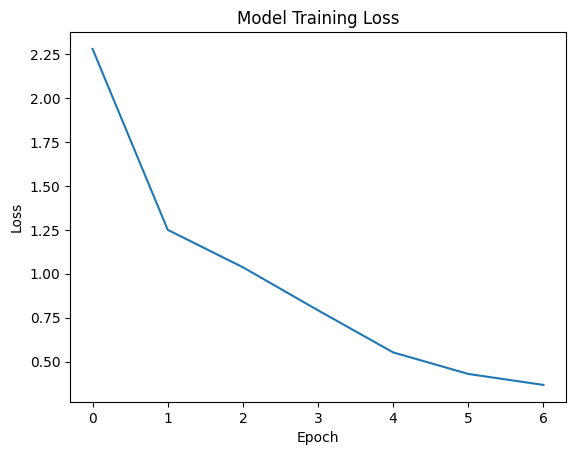

In [60]:
plt.plot(history.history["loss"])
plt.title("Model Training Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## Testing Fairness

In [61]:
# 0. Define a symbolic input with the correct shape (batch_size, 2)
inputs = layers.Input(shape=(2,))

# 1. Define the embedding model using the internal layers of your RecommenderNet
# This bypasses the 'model.input' attribute issue
embedding_model = keras.Model(
    inputs=inputs,
    outputs=[
        model.user_embedding_biased_mlp(inputs[:, 0]),
        model.user_embedding_fair_mlp(inputs[:, 0])
    ]
)

# 2. Now you can safely run the prediction
u_b_vectors, u_d_vectors = embedding_model.predict(x_train)
print("Vectors extracted successfully. Shape:", u_b_vectors.shape)

584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Vectors extracted successfully. Shape: (18674, 50)


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Prepare the ground truth (the gender labels)
y_gender = yg[:train_indices]

# 2. Test the BIASED vectors (u^b)
clf_b = LogisticRegression(max_iter=1000).fit(u_b_vectors, y_gender)
acc_b = clf_b.score(u_b_vectors, y_gender)

# 3. Test the FAIR vectors (u^d)
clf_d = LogisticRegression(max_iter=1000).fit(u_d_vectors, y_gender)
acc_d = clf_d.score(u_d_vectors, y_gender)

print(f"Can we guess gender from the Biased vector (u^b)? Accuracy: {acc_b:.4f}")
print(f"Can we guess gender from the Fair vector (u^d)? Accuracy: {acc_d:.4f}")

Can we guess gender from the Biased vector (u^b)? Accuracy: 1.0000
Can we guess gender from the Fair vector (u^d)? Accuracy: 1.0000
